Dataset shape: (17467, 19)

Columns:
 ['dataset', 'source_dataset', 'target', 'binder', 'sequence', 'kd_M', 'pKD', 'binding_binary', 'binding_strength', 'assay_method', 'structure_method', 'design_method', 'plddt', 'pae_interaction', 'iptm', 'ipSAE_min', 'esm_pll', 'rosetta_interface_dG', 'dG_kcal_mol']

First 5 rows:
        dataset source_dataset                target  \
0  PPB-Affinity    SKEMPI v2.0   hGH binding protein   
1  PPB-Affinity    SKEMPI v2.0            Angiogenin   
2  PPB-Affinity    SKEMPI v2.0               Eglin c   
3  PPB-Affinity    SKEMPI v2.0         Tissue factor   
4  PPB-Affinity    SKEMPI v2.0  HIV-1 capsid protein   

                      binder sequence          kd_M        pKD  \
0       Human growth hormone      NaN  9.000000e-10   9.045757   
1     Ribonuclease inhibitor      NaN  5.000000e-16  15.301030   
2  Bovine alpha-chymotrypsin      NaN  1.490000e-12  11.826814   
3     Immunoglobulin fab 5G9      NaN  3.400000e-09   8.468521   
4            

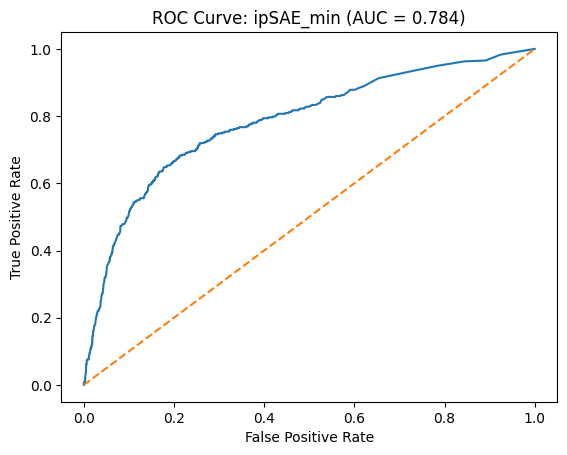

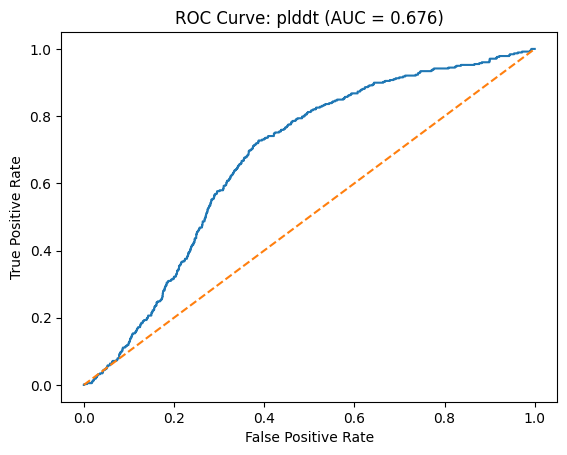

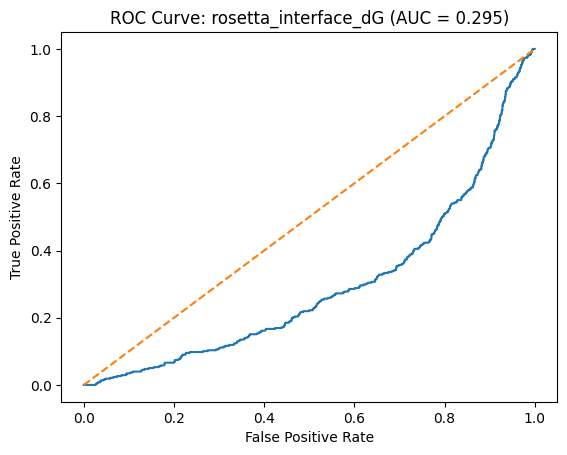

ipSAE AUC: 0.7838379171600984
pLDDT AUC: 0.6755010877627137
Rosetta dG AUC: 0.2953448358266023

Logistic Regression for: ipSAE_min
                           Logit Regression Results                           
Dep. Variable:         binding_binary   No. Observations:                 3367
Model:                          Logit   Df Residuals:                     3365
Method:                           MLE   Df Model:                            1
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                  0.1633
Time:                        16:59:11   Log-Likelihood:                -989.41
converged:                       True   LL-Null:                       -1182.6
Covariance Type:            nonrobust   LLR p-value:                 5.170e-86
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.4437      0.116    -29.687      0.000      -3.671      -3.216


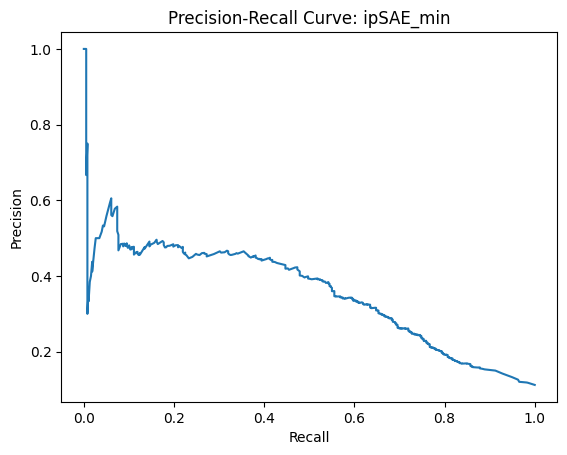

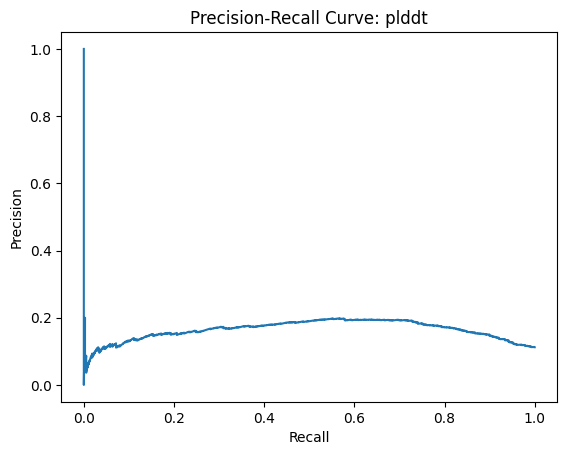

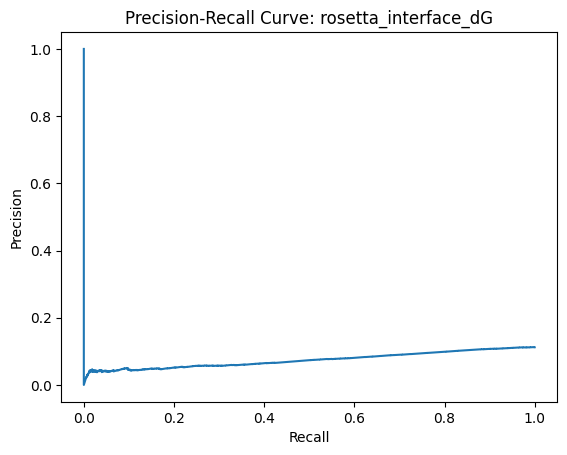


Analysis complete.


In [3]:
# ==============================
# 1. LOAD DATA
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
import statsmodels.api as sm

# Load dataset
df = pd.read_csv("./merged_all.csv")

print("Dataset shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

# ==============================
# 2. BASIC DATA VALIDATION
# ==============================

print("\nFirst 5 rows:")
print(df.head())

print("\nBinding distribution:")
print(df["binding_binary"].value_counts())

print("\nBinding distribution (percentage):")
print(df["binding_binary"].value_counts(normalize=True))

# Check for missing values in key columns
key_metrics = [
    "ipSAE_min",
    "plddt",
    "rosetta_interface_dG"
]

print("\nMissing values in key metrics:")
print(df[["binding_binary"] + key_metrics].isna().sum())

# Drop rows with missing values for fair comparison
df_clean = df[["binding_binary"] + key_metrics].dropna()

print("\nCleaned dataset shape:", df_clean.shape)

y = df_clean["binding_binary"]

# ==============================
# 3. ROC + AUC ANALYSIS
# ==============================

def compute_roc(metric_name):
    X = df_clean[metric_name]
    
    fpr, tpr, thresholds = roc_curve(y, X)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {metric_name} (AUC = {roc_auc:.3f})")
    plt.show()
    
    return roc_auc

print("\nAUC Results:")
auc_ipsae = compute_roc("ipSAE_min")
auc_plddt = compute_roc("plddt")
auc_ros = compute_roc("rosetta_interface_dG")

print("ipSAE AUC:", auc_ipsae)
print("pLDDT AUC:", auc_plddt)
print("Rosetta dG AUC:", auc_ros)

# ==============================
# 4. LOGISTIC REGRESSION
# ==============================

def logistic_regression(metric_name):
    X = df_clean[[metric_name]]
    X = sm.add_constant(X)
    model = sm.Logit(y, X)
    result = model.fit(disp=False)
    
    print("\nLogistic Regression for:", metric_name)
    print(result.summary())
    
    odds_ratio = np.exp(result.params)
    print("\nOdds Ratios:")
    print(odds_ratio)
    
    return result

log_ipsae = logistic_regression("ipSAE_min")
log_plddt = logistic_regression("plddt")
log_ros = logistic_regression("rosetta_interface_dG")

# ==============================
# 5. PRECISION-RECALL (IMBALANCE CHECK)
# ==============================

def compute_pr(metric_name):
    X = df_clean[metric_name]
    precision, recall, _ = precision_recall_curve(y, X)
    
    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve: {metric_name}")
    plt.show()

compute_pr("ipSAE_min")
compute_pr("plddt")
compute_pr("rosetta_interface_dG")

print("\nAnalysis complete.")